# Qadence Kickstart: Feature Maps, Kernels & Kernel Machines

**Lessons 02 + 03 of the QML study guide.**

This notebook builds the conceptual core of *kernel-based* quantum machine learning:

1. **Feature maps** — lifting data into a higher-dimensional space to make hard problems easy.
2. **The kernel trick** — computing inner products in that space *without ever building the feature vectors*.
3. **Gram matrices** — the single object every kernel method consumes, and how to read its health.
4. **Kernel concentration** — the failure mode that decides whether *any* kernel (classical or quantum) is useful.
5. **Kernel Ridge Regression** and the **SVM** — the two learners that turn a kernel into predictions.

> **Why this is the heart of near-term QML.** Pasqal's **Quantum Evolution Kernel (QEK)** encodes a graph
> into a Rydberg Hamiltonian, evolves the quantum state, and reads out a similarity — *that similarity is a
> kernel value*. A quantum kernel is **literally a feature map into a Hilbert space followed by an inner product**.
> Everything below transfers directly to the quantum case: only the feature map `φ` becomes quantum, while the
> downstream KRR/SVM code stays **identical**. That swap-ability is exactly why Pasqal ships QEK as a drop-in kernel.


## Setup

One import block and one helper — the **RBF (Gaussian) kernel** — reused throughout. Run this first.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(20000)

def rbf_kernel(A, B, sigma=1.0):
    """k(x, x') = exp(-||x - x'||^2 / (2 sigma^2)).

    An inner product in an *infinite*-dimensional feature space, yet trivial to compute.
    A and B are (n, d) and (m, d); returns the (n, m) matrix of pairwise kernel values.
    """
    sq = torch.cdist(A, B) ** 2          # squared Euclidean distance, every row vs every row
    return torch.exp(-sq / (2 * sigma ** 2))

print("setup ready — rbf_kernel defined")

setup ready — rbf_kernel defined


---
# Lesson 02 — Feature Maps & Kernels

## 1. The idea: make hard problems linear by *lifting*

Some data isn't linearly separable in its raw coordinates but becomes separable after mapping into a
higher-dimensional space. That map `φ` is the **feature map**.

Classic example: 1-D points where the **inner** ones are one class and the **outer** ones another. No single
threshold on `x` can split them. But lift each point with `φ(x) = [x, x²]` and the `x²` coordinate alone
separates inner (small) from outer (large) — a flat line does the job in the lifted space.

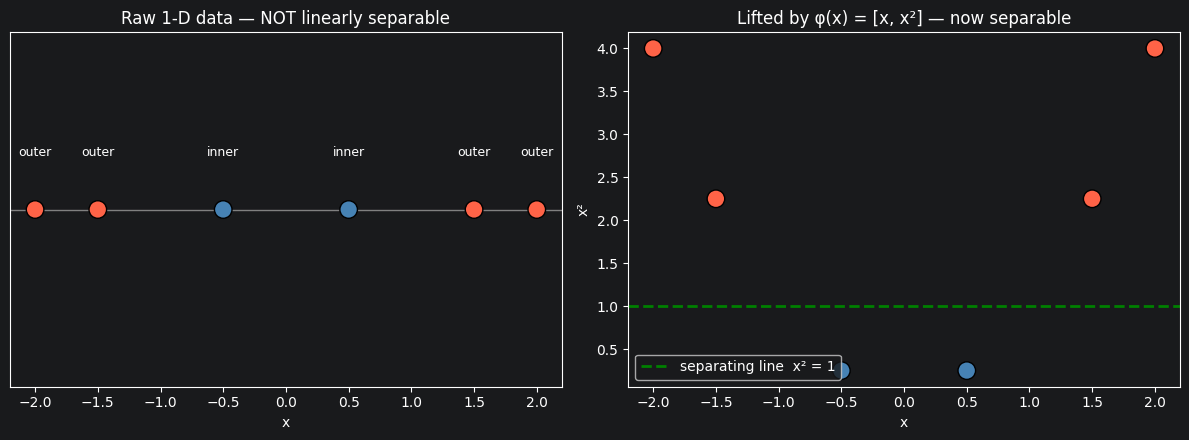

phi =
 tensor([[-2.0000,  4.0000],
        [-1.5000,  2.2500],
        [-0.5000,  0.2500],
        [ 0.5000,  0.2500],
        [ 1.5000,  2.2500],
        [ 2.0000,  4.0000]])


In [2]:
# 1-D data that is NOT linearly separable: inner points one class, outer another
x     = torch.tensor([-2.0, -1.5, -0.5, 0.5, 1.5, 2.0])
label = torch.tensor([   1,    1,    0,   0,   1,   1])   # 0 = inner, 1 = outer

# feature map  phi(x) = [x, x^2]
phi = torch.stack([x, x ** 2], dim=1)

colors = ['tomato' if l == 1 else 'steelblue' for l in label]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# left: raw 1-D — no single threshold on x separates the two classes
ax1.scatter(x, torch.zeros_like(x), c=colors, s=160, zorder=3, edgecolor='k')
ax1.axhline(0, color='gray', lw=1)
for xi, li in zip(x, label):
    ax1.annotate('outer' if li == 1 else 'inner', (xi, 0.015), ha='center', fontsize=9)
ax1.set_title('Raw 1-D data — NOT linearly separable')
ax1.set_xlabel('x'); ax1.set_yticks([]); ax1.set_ylim(-0.05, 0.05)

# right: lifted to (x, x^2) — a horizontal line now separates the classes
ax2.scatter(phi[:, 0], phi[:, 1], c=colors, s=160, zorder=3, edgecolor='k')
ax2.axhline(1.0, color='green', ls='--', lw=2, label='separating line  x² = 1')
ax2.set_title('Lifted by φ(x) = [x, x²] — now separable')
ax2.set_xlabel('x'); ax2.set_ylabel('x²'); ax2.legend()

plt.tight_layout(); plt.show()
print('phi =\n', phi)

The catch: useful feature maps can be **enormous** — even infinite-dimensional. Building `φ(x)` explicitly is
often impossible. That is exactly the problem the kernel trick solves.

## 2. The kernel trick

A **kernel** computes the inner product in feature space *without ever building the feature vectors*:

$$k(x, x') = \langle \varphi(x),\, \varphi(x') \rangle$$

Many algorithms (SVM, ridge regression, PCA) only ever touch the data through inner products. Swap those inner
products for `k(x, x')` and you operate in feature space **for free**.

Let's *prove* the equivalence on a concrete map. For the explicit feature map
`φ(x) = [1, √2·x, x²]`, the inner product `⟨φ(x), φ(x')⟩` expands to
`1 + 2xx' + x²x'² = (1 + xx')²` — the **degree-2 polynomial kernel**. We can compute it either way and check
they agree.

In [3]:
# explicit feature map phi(x) = [1, sqrt(2) x, x^2]   (for scalar x)
def phi_poly(x):
    return torch.stack([torch.ones_like(x), torch.sqrt(torch.tensor(2.0)) * x, x ** 2], dim=1)

a = torch.tensor([0.5, -1.0, 2.0])
b = torch.tensor([1.0,  0.3, -0.5])

explicit = phi_poly(a) @ phi_poly(b).T     # build 3-D features, then inner product
kernel   = (1 + torch.outer(a, b)) ** 2    # never build features: (1 + x x')^2

print('explicit  ⟨φ(x), φ(x\')⟩:\n', explicit.round(decimals=4))
print("kernel    (1 + x x')^2  :\n", kernel.round(decimals=4))
print('\nmatch (within float32 precision):', torch.allclose(explicit, kernel, atol=1e-5))

explicit  ⟨φ(x), φ(x')⟩:
 tensor([[2.2500, 1.3225, 0.5625],
        [0.0000, 0.4900, 2.2500],
        [9.0000, 2.5600, 0.0000]])
kernel    (1 + x x')^2  :
 tensor([[2.2500, 1.3225, 0.5625],
        [0.0000, 0.4900, 2.2500],
        [9.0000, 2.5600, 0.0000]])

match (within float32 precision): True


This is the trick that makes a **quantum** kernel usable: you never materialize the exponentially large
state vector, you just need the overlaps — and a quantum device gives you those directly.

## 3. Building Gram matrices

The **Gram matrix** `K` collects all pairwise kernel values: `K[i, j] = k(xᵢ, xⱼ)`. It is the single object
every kernel method consumes. Two kernels, side by side:

- **Linear kernel:** `K = X Xᵀ` — just inner products of the raw vectors.
- **RBF kernel:** similarity decays with distance, so nearby points light up and far points go dark.

Using **sorted 1-D points** makes the structure pop in the heatmap: the RBF Gram matrix becomes a bright
**diagonal band** (each point is similar only to its neighbours).

linear kernel symmetric: True
RBF diagonal (self-similarity = 1): [1.0, 1.0, 1.0, 1.0, 1.0]


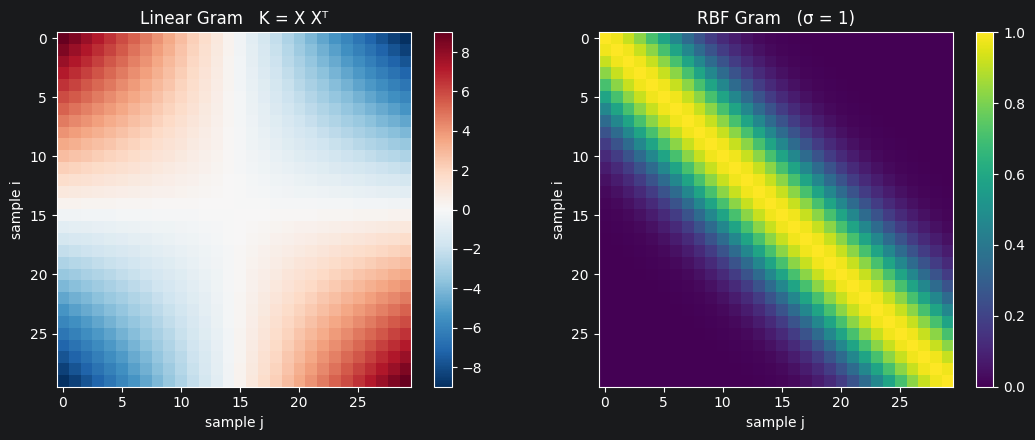

In [4]:
X = torch.linspace(-3, 3, 30).unsqueeze(1)     # 30 sorted 1-D points

K_lin = X @ X.T                                # linear Gram
K_rbf = rbf_kernel(X, X, sigma=1.0)            # RBF Gram

print('linear kernel symmetric:', torch.allclose(K_lin, K_lin.T))
print('RBF diagonal (self-similarity = 1):', torch.diag(K_rbf)[:5].tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
im1 = ax1.imshow(K_lin, cmap='RdBu_r'); ax1.set_title('Linear Gram   K = X Xᵀ')
plt.colorbar(im1, ax=ax1, fraction=0.046)
im2 = ax2.imshow(K_rbf, cmap='viridis', vmin=0, vmax=1); ax2.set_title('RBF Gram   (σ = 1)')
plt.colorbar(im2, ax=ax2, fraction=0.046)
for ax in (ax1, ax2):
    ax.set_xlabel('sample j'); ax.set_ylabel('sample i')
plt.tight_layout(); plt.show()

Read two structural facts off any Gram matrix — they decide whether a kernel is useful:

- **Symmetric:** `K == Kᵀ`.
- **Diagonal = self-similarity.** If the *off*-diagonal entries all collapse toward zero (every point looks
  dissimilar to every other), the kernel is **uninformative** — the matrix drifts toward the identity and
  learning fails. This is precisely the **exponential concentration** failure mode of quantum kernels
  (Lesson 06). We can see a classical preview of it right now.

## 4. Kernel concentration — the make-or-break property

Sweep the RBF bandwidth `σ` and watch the **mean off-diagonal** value of `K`:

- **σ → 0:** every point looks dissimilar to every other → `K → identity` → nothing to learn from.
- **σ → ∞:** every point looks identical to every other → `K → all-ones` → again nothing to learn from.

Only the **middle régime** carries usable structure. A quantum kernel that concentrates (its Gram matrix drifts
to the identity as you add qubits) is the central obstacle in quantum kernel methods — this plot is the
intuition you'll carry into Lesson 06.

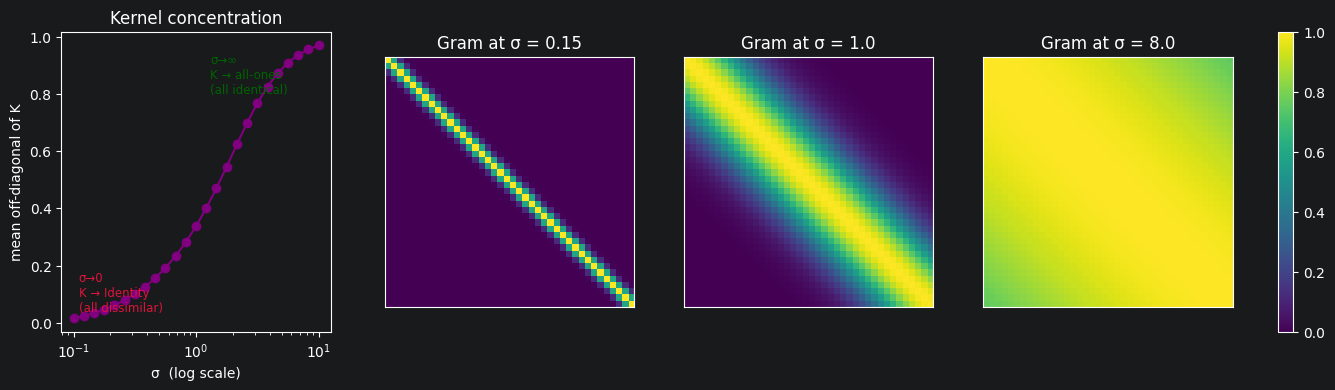

σ=0.15 mean off-diag = 0.016  (near 0 → identity-like, useless)
σ=8.0  mean off-diag = 0.969  (near 1 → all-ones,  useless)


In [5]:
X = torch.linspace(-3, 3, 40).unsqueeze(1)
sigmas = torch.logspace(-1, 1, 25)             # 0.1 ... 10
off_mask = ~torch.eye(len(X), dtype=bool)

mean_off = [rbf_kernel(X, X, s.item())[off_mask].mean().item() for s in sigmas]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.9))

axes[0].semilogx(sigmas, mean_off, 'o-', color='purple')
axes[0].set_xlabel('σ  (log scale)'); axes[0].set_ylabel('mean off-diagonal of K')
axes[0].set_title('Kernel concentration')
axes[0].annotate('σ→0\nK → Identity\n(all dissimilar)', xy=(0.11, 0.04),
                 fontsize=8.5, color='crimson')
axes[0].annotate('σ→∞\nK → all-ones\n(all identical)', xy=(1.3, 0.80),
                 fontsize=8.5, color='darkgreen')

for ax, s in zip(axes[1:], [0.15, 1.0, 8.0]):
    im = ax.imshow(rbf_kernel(X, X, s), cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'Gram at σ = {s}'); ax.set_xticks([]); ax.set_yticks([])

plt.colorbar(im, ax=axes[1:], fraction=0.025)
plt.show()
print('σ=0.15 mean off-diag = %.3f  (near 0 → identity-like, useless)' % mean_off[0])
print('σ=8.0  mean off-diag = %.3f  (near 1 → all-ones,  useless)'  % mean_off[-1])

## 5. A kernel is an *interface*, not an algorithm

The payoff: define a feature map → get a kernel → hand the Gram matrix to a learner. The learner doesn't care
where `K` came from. Here is a tiny **kernel nearest-centroid** classifier on two Gaussian blobs: classify each
point by which class it is, on average, most *similar* to (via the kernel). We visualize its full decision
boundary on a grid.

To switch to a **quantum** kernel you would replace `rbf_kernel` with quantum-state overlaps (QEK's job) — and
**this classifier would not change a single line**.

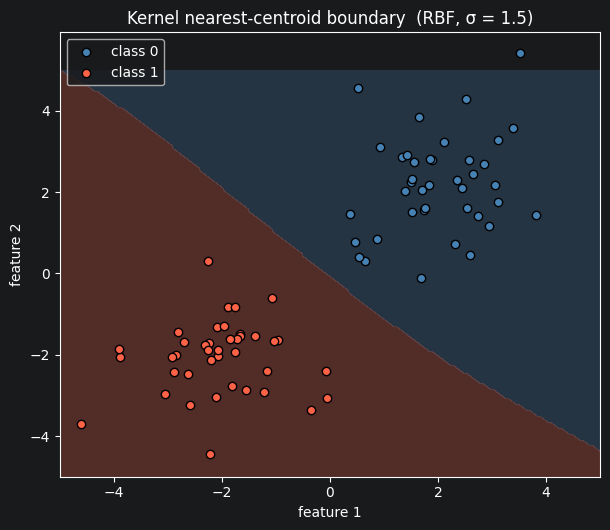

predictions for [+2,+2] and [-2,-2]: [0, 1] (expect [0, 1])


In [6]:
torch.manual_seed(0)
Xtr = torch.cat([torch.randn(40, 2) + 2, torch.randn(40, 2) - 2])   # two blobs
ytr = torch.cat([torch.zeros(40), torch.ones(40)]).long()

def knc_predict(Xte, Xtr, ytr, sigma=1.5):
    K = rbf_kernel(Xte, Xtr, sigma)                  # (#test, #train)
    score0 = K[:, ytr == 0].mean(dim=1)              # avg similarity to class 0
    score1 = K[:, ytr == 1].mean(dim=1)              # avg similarity to class 1
    return (score1 > score0).long()

# evaluate the classifier on a dense grid to draw its decision boundary
g = torch.linspace(-5, 5, 200)
G1, G2 = torch.meshgrid(g, g, indexing='xy')
grid = torch.stack([G1.reshape(-1), G2.reshape(-1)], dim=1)
Z = knc_predict(grid, Xtr, ytr, sigma=1.5).reshape(G1.shape)

plt.figure(figsize=(6.2, 5.4))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5], colors=['steelblue', 'tomato'], alpha=0.25)
plt.scatter(Xtr[ytr == 0, 0], Xtr[ytr == 0, 1], c='steelblue', edgecolor='k', label='class 0')
plt.scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c='tomato',    edgecolor='k', label='class 1')
plt.title('Kernel nearest-centroid boundary  (RBF, σ = 1.5)')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.legend()
plt.tight_layout(); plt.show()

# sanity check on two obvious test points
Xte = torch.tensor([[2.0, 2.0], [-2.0, -2.0]])
print('predictions for [+2,+2] and [-2,-2]:', knc_predict(Xte, Xtr, ytr).tolist(), '(expect [0, 1])')

## 6. Why a kernel must be PSD

A valid kernel matrix must be **positive semi-definite (PSD)**: all eigenvalues `≥ 0` (up to numerical noise).
The reason is structural — since `k(x, x') = ⟨φ(x), φ(x')⟩`, the Gram matrix factors as `K = Φ Φᵀ`, which is
*always* PSD. PSD is also what makes the SVM / KRR optimization **convex** (a unique, findable solution). A
"kernel" that isn't PSD isn't really an inner product in any feature space — and breaks the learner.

In [7]:
torch.manual_seed(0)
Xr = torch.randn(8, 3)
for name, K in [('linear', Xr @ Xr.T), ('rbf', rbf_kernel(Xr, Xr, 1.0))]:
    min_eig = torch.linalg.eigvalsh(K).min().item()
    print(f'{name:>7}:  min eigenvalue = {min_eig:+.3e}   ->  PSD: {min_eig >= -1e-6}')

 linear:  min eigenvalue = -4.217e-07   ->  PSD: True
    rbf:  min eigenvalue = +1.370e-01   ->  PSD: True


---
# Lesson 03 — Kernel Ridge Regression & SVM

We now build the two learners that *consume* a kernel. The lesson: **swapping the kernel is the only change
needed to go quantum.** Produce `K` with a quantum device → feed it to the exact same code below.

## 1. Kernel Ridge Regression (KRR) in closed form

Ridge regression in feature space has a clean closed-form solution that touches the data **only** through `K`:

$$\alpha = (K + \lambda I)^{-1}\, y, \qquad \hat{y}(x) = \sum_i \alpha_i\, k(x, x_i)$$

`λ` is the regularization strength. **No gradient descent** — just one linear solve. That makes KRR the
cleanest way to test a new kernel. Here we fit a noisy sine.

train MSE: 0.0068


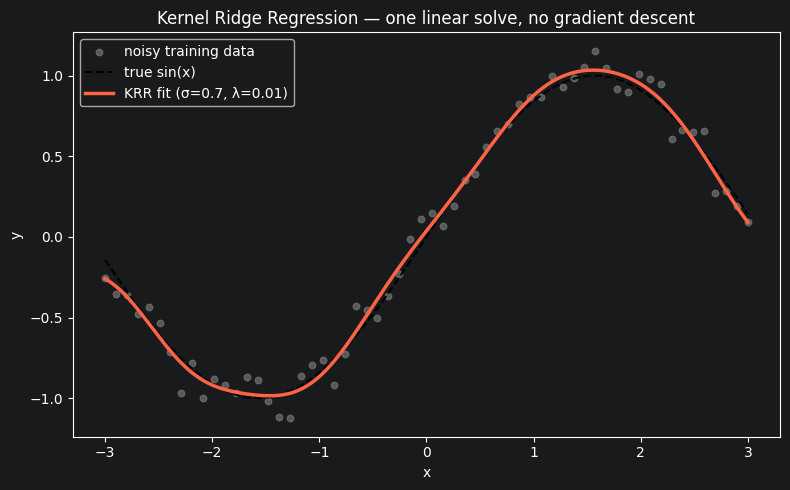

In [8]:
torch.manual_seed(0)
Xtr = torch.linspace(-3, 3, 60).unsqueeze(1)
ytr = torch.sin(Xtr).squeeze(1) + 0.1 * torch.randn(60)     # noisy sine
Xte = torch.linspace(-3, 3, 200).unsqueeze(1)

sigma, lam = 0.7, 1e-2
K = rbf_kernel(Xtr, Xtr, sigma)                  # (60, 60)
I = torch.eye(K.shape[0])
alpha = torch.linalg.solve(K + lam * I, ytr)     # the ENTIRE learning step

y_pred = rbf_kernel(Xte, Xtr, sigma) @ alpha     # predict on a dense grid
train_mse = (((K @ alpha) - ytr) ** 2).mean().item()
print(f'train MSE: {train_mse:.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(Xtr, ytr, s=22, c='gray', alpha=0.6, label='noisy training data')
plt.plot(Xte, torch.sin(Xte), 'k--', lw=1.5, label='true sin(x)')
plt.plot(Xte, y_pred, 'tomato', lw=2.5, label=f'KRR fit (σ={sigma}, λ={lam})')
plt.title('Kernel Ridge Regression — one linear solve, no gradient descent')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.tight_layout(); plt.show()

To make this a **quantum** KRR, replace the two `rbf_kernel(...)` calls with quantum-kernel evaluations and
change nothing else.

## 2. The role of λ — bias vs. variance

`λ` controls the bias–variance trade-off: **small λ** fits the training data hard (wiggly curve, huge
coefficients → overfitting); **large λ** smooths everything (flat curve → underfitting). Watch the fitted
curve and the largest coefficient `|α|max` change together as we sweep `λ`. This is your first taste of
Lesson 05 (generalization).

lambda=  0.0001:  train MSE=0.0062   |alpha|max=1725.04
lambda=    0.01:  train MSE=0.0068   |alpha|max=18.30
lambda=     1.0:  train MSE=0.0101   |alpha|max=0.26
lambda=   100.0:  train MSE=0.4182   |alpha|max=0.01


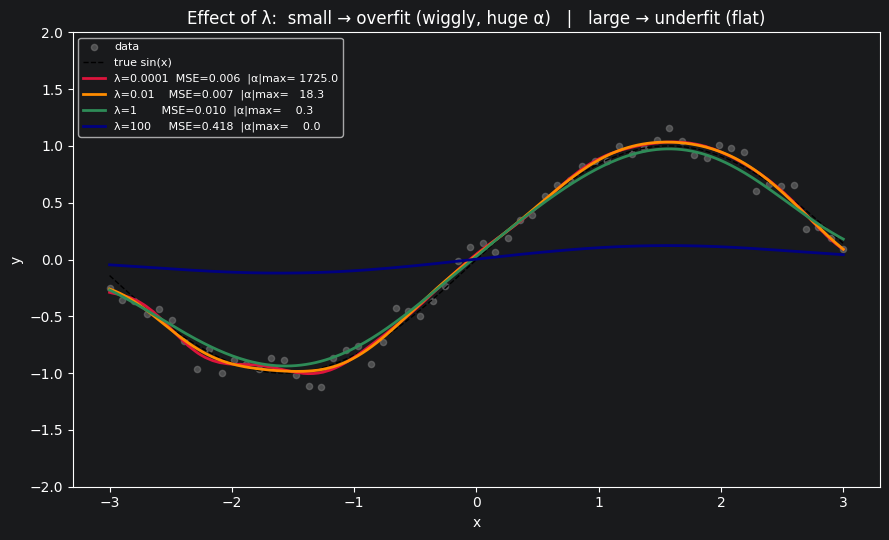

In [9]:
torch.manual_seed(0)
Xtr = torch.linspace(-3, 3, 60).unsqueeze(1)
ytr = torch.sin(Xtr).squeeze(1) + 0.1 * torch.randn(60)
Xte = torch.linspace(-3, 3, 300).unsqueeze(1)

K    = rbf_kernel(Xtr, Xtr, 0.7); I = torch.eye(len(K))
K_te = rbf_kernel(Xte, Xtr, 0.7)

plt.figure(figsize=(9, 5.5))
plt.scatter(Xtr, ytr, s=20, c='gray', alpha=0.5, label='data')
plt.plot(Xte, torch.sin(Xte), 'k--', lw=1, label='true sin(x)')

for lam, col in zip([1e-4, 1e-2, 1.0, 100.0], ['crimson', 'darkorange', 'seagreen', 'navy']):
    alpha = torch.linalg.solve(K + lam * I, ytr)
    train_mse = (((K @ alpha) - ytr) ** 2).mean().item()
    amax = alpha.abs().max().item()
    plt.plot(Xte, K_te @ alpha, color=col, lw=2,
             label=f'λ={lam:<6g}  MSE={train_mse:.3f}  |α|max={amax:7.1f}')
    print(f'lambda={lam:>8}:  train MSE={train_mse:.4f}   |alpha|max={amax:.2f}')

plt.title('Effect of λ:  small → overfit (wiggly, huge α)   |   large → underfit (flat)')
plt.xlabel('x'); plt.ylabel('y'); plt.ylim(-2, 2); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

Tiny `λ` drives train MSE → 0 but the coefficients explode (`|α|max` in the thousands) — textbook
overfitting. Large `λ` underfits. The "right" `λ` is chosen by **cross-validation**, never by training error.

## 3. SVM with a *precomputed* kernel

The SVM is the classic maximum-margin kernel classifier. Writing the quadratic-program solver from scratch is
fiddly, so we use scikit-learn with a **precomputed** Gram matrix — which is exactly the realistic QEK
workflow: the kernel comes from *elsewhere* (a quantum device) and sklearn does the classical optimization.

`kernel="precomputed"` is **the entire integration point.** We visualize the learned decision function, the
zero-level margin boundary, and the **support vectors** (the points that actually define the margin).

SVM test accuracy: 95.00%   |   support vectors per class: [9 9]


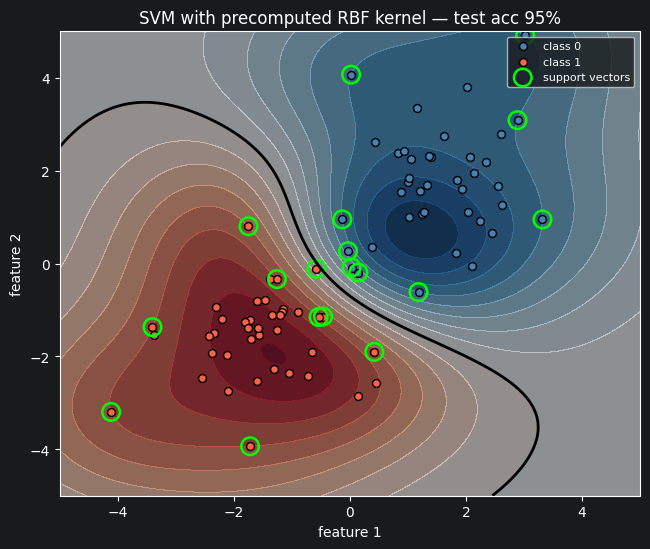

In [10]:
from sklearn.svm import SVC

torch.manual_seed(0)
Xtr = torch.cat([torch.randn(40, 2) + 1.5, torch.randn(40, 2) - 1.5])   # interleaving blobs
ytr = torch.cat([torch.zeros(40), torch.ones(40)]).long()
Xte = torch.cat([torch.randn(20, 2) + 1.5, torch.randn(20, 2) - 1.5])
yte = torch.cat([torch.zeros(20), torch.ones(20)]).long()

sigma = 1.5
K_tr = rbf_kernel(Xtr, Xtr, sigma).numpy()       # (80, 80) train-train
K_te = rbf_kernel(Xte, Xtr, sigma).numpy()       # (40, 80) test-train

clf = SVC(kernel='precomputed', C=1.0)           # <-- the only quantum integration point
clf.fit(K_tr, ytr.numpy())
acc = (clf.predict(K_te) == yte.numpy()).mean()
print(f'SVM test accuracy: {acc:.2%}   |   support vectors per class: {clf.n_support_}')

# decision surface: every grid point needs its kernel against the TRAIN points
g = torch.linspace(-5, 5, 150)
G1, G2 = torch.meshgrid(g, g, indexing='xy')
grid = torch.stack([G1.reshape(-1), G2.reshape(-1)], dim=1)
K_grid = rbf_kernel(grid, Xtr, sigma).numpy()
Zd = clf.decision_function(K_grid).reshape(G1.shape)

plt.figure(figsize=(6.6, 5.6))
plt.contourf(G1, G2, Zd, levels=20, cmap='RdBu_r', alpha=0.55)
plt.contour(G1, G2, Zd, levels=[0], colors='k', linewidths=2)          # margin boundary
plt.scatter(Xtr[ytr == 0, 0], Xtr[ytr == 0, 1], c='steelblue', edgecolor='k', s=32, label='class 0')
plt.scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c='tomato',    edgecolor='k', s=32, label='class 1')
sv = clf.support_
plt.scatter(Xtr[sv, 0], Xtr[sv, 1], s=160, facecolors='none', edgecolors='lime',
            linewidths=1.8, label='support vectors')
plt.title(f'SVM with precomputed RBF kernel — test acc {acc:.0%}')
plt.xlabel('feature 1'); plt.ylabel('feature 2'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

QEK produces `K_tr` and `K_te` from a Rydberg processor; **this code is unchanged**. Pasqal used exactly
this pattern — a quantum graph kernel feeding a classical kernel classifier — to predict molecular toxicity on
neutral-atom hardware.

## 4. Sweeping `C` — where overfitting begins

`C` is the SVM's regularization knob: **large C** penalizes margin violations harder, fitting the training set
more tightly (overfitting risk); **small C** allows a softer, smoother margin. Plotting train vs. test accuracy
across `C` shows the classic gap opening up.

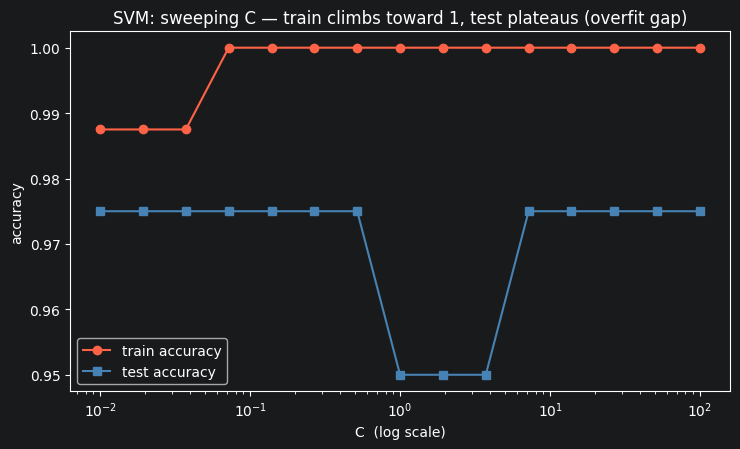

In [11]:
Cs = np.logspace(-2, 2, 15)
tr_acc, te_acc = [], []
for C in Cs:
    c = SVC(kernel='precomputed', C=C).fit(K_tr, ytr.numpy())
    tr_acc.append((c.predict(K_tr) == ytr.numpy()).mean())
    te_acc.append((c.predict(K_te) == yte.numpy()).mean())

plt.figure(figsize=(7.5, 4.6))
plt.semilogx(Cs, tr_acc, 'o-', color='tomato',    label='train accuracy')
plt.semilogx(Cs, te_acc, 's-', color='steelblue', label='test accuracy')
plt.xlabel('C  (log scale)'); plt.ylabel('accuracy')
plt.title('SVM: sweeping C — train climbs toward 1, test plateaus (overfit gap)')
plt.legend(); plt.tight_layout(); plt.show()

## 5. The kernel must carry *real* structure

The learner is kernel-agnostic — but that cuts both ways. Replace the RBF Gram matrix with a **random PSD
matrix** of the same size (a valid kernel, just structure-free) and accuracy collapses to chance. The kernel,
not the learner, is where the problem's structure lives. **This is the entire burden a quantum kernel must
carry**: producing a `K` that actually encodes the data's geometry.

In [12]:
from sklearn.svm import SVC

torch.manual_seed(1)
n_tr = len(Xtr)
R  = torch.randn(n_tr, n_tr)
K_rand_tr = (R @ R.T).numpy()                     # random PSD = Gram of random vectors
R2 = torch.randn(len(Xte), n_tr)
K_rand_te = (R2 @ R.T).numpy()                    # structure-free test-train block

clf_r = SVC(kernel='precomputed', C=1.0).fit(K_rand_tr, ytr.numpy())
acc_r = (clf_r.predict(K_rand_te) == yte.numpy()).mean()

print(f'RBF kernel   test accuracy: {acc:.2%}')
print(f'random PSD   test accuracy: {acc_r:.2%}   <- structure-free kernel learns nothing')

RBF kernel   test accuracy: 95.00%
random PSD   test accuracy: 52.50%   <- structure-free kernel learns nothing


## The big picture

```
          CLASSICAL                                         QUANTUM  (Pasqal QEK)
 data ─► φ (RBF/poly) ─► Gram K ─► KRR / SVM      data(graph) ─► Rydberg evolution ─► K ─► KRR / SVM
                              └────────────── identical downstream code ──────────────┘
```

The learner is **kernel-agnostic**. That is *why* quantum kernels are an attractive near-term QML strategy: the
quantum computer only has to produce a good `K`; decades of classical kernel machinery does the rest.

**What carried over from Lesson 01:** nothing about the training *loop* changed conceptually — KRR even
replaces it with a single `torch.linalg.solve`. **What you'll carry into Lesson 06:** the concentration plot
(§4 of Lesson 02) is the obstacle quantum kernels must beat. **Next:** Lesson 04 applies all of this to
*graphs*, which is the native input format for QEK.